In [2]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds_sealevel = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")
# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['latitude'].values
lons = ds_sealevel['longitude'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

In [3]:
# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.where(
        (ds.lat >= lat - half) & (ds.lat <= lat + half) &
        (ds.lon >= lon - half) & (ds.lon <= lon + half),
        drop=True  # drops points outside the box
    )
for lat, lon in unique_latlon:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))


In [5]:
results

{'0.1x0.1': [<xarray.Dataset>
  Dimensions:    (lat: 24, lon: 24)
  Coordinates:
    * lat        (lat) float64 60.11 60.11 60.11 60.12 ... 60.19 60.19 60.2 60.2
    * lon        (lon) float64 -1.19 -1.185 -1.181 -1.177 ... -1.102 -1.098 -1.094
  Data variables:
      elevation  (lat, lon) float32 -46.0 -43.0 -42.0 -42.0 ... -47.0 -48.0 -49.0
  Attributes: (12/36)
      title:                           The GEBCO_2024 Grid - a continuous terra...
      summary:                         The GEBCO_2024 Grid is a continuous, glo...
      keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
      Conventions:                     CF-1.6, ACDD-1.3
      id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
      naming_authority:                https://dx.doi.org
      ...                              ...
      geospatial_vertical_units:       meters
      geospatial_vertical_resolution:  1.0
      geospatial_vertical_positive:    up
      identif

In [6]:
del GEBCO_ds

# Open ERA5 datasets

In [7]:
import zipfile
import os

# Source folder where zip files are stored
source_folder = "/Users/lb962/Documents/GitHub/ESL/data/ERA5_by_location"

# Destination folder where everything will be unzipped
dest_folder = os.path.join(source_folder, "unzipped")
os.makedirs(dest_folder, exist_ok=True)

for file in os.listdir(source_folder):
    if file.lower().endswith(".zip"):  # only process .zip files
        file_path = os.path.join(source_folder, file)

        extract_dir = os.path.join(dest_folder, os.path.splitext(file)[0])
        os.makedirs(extract_dir, exist_ok=True)

        try:
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
        except zipfile.BadZipFile:
            print(f"⚠️ Skipping bad zip file: {file}")
    else:
        print(f"Skipping non-zip file: {file}")


Skipping non-zip file: unzipped
Skipping non-zip file: .DS_Store
⚠️ Skipping bad zip file: ERA5_55.00_-8.50.zip


In [8]:
import os
import glob
import xarray as xr
import numpy as np

unzipped_root = "/Users/lb962/Documents/GitHub/ESL/data/ERA5_by_location/unzipped"

nc_files = sorted(glob.glob(os.path.join(unzipped_root, "**", "*.nc"), recursive=True))
if not nc_files:
    raise FileNotFoundError(f"No .nc files found under: {unzipped_root}")
print(f"Found {len(nc_files)} NetCDF files")

def promote_latlon_to_dims(ds: xr.Dataset) -> xr.Dataset:
    """Ensure latitude/longitude are dims (length-1) so open_mfdataset can concat by coords."""
    # normalize coordinate names
    rename_map = {}
    if "lat" in ds and "latitude" not in ds:   rename_map["lat"] = "latitude"
    if "lon" in ds and "longitude" not in ds: rename_map["lon"] = "longitude"
    if rename_map:
        ds = ds.rename(rename_map)

    # make sure they are coords (not just data variables)
    for c in ("latitude", "longitude"):
        if c in ds and c not in ds.coords:
            ds = ds.set_coords(c)

    # promote scalars to 1-length dims
    for c in ("latitude", "longitude"):
        if c in ds:
            if ds[c].ndim == 0:
                # scalar -> 1D with itself as the sole value
                val = ds[c].values.item() if np.ndim(ds[c].values) == 0 else ds[c].values
                ds = ds.expand_dims({c: [val]})
            elif ds[c].ndim == 1:
                # already a dim-sized coord; ensure it's a dimension
                if c not in ds.dims:
                    # if 1D coord but not a dimension, try to set index
                    ds = ds.set_index({c: ds[c]})
            else:
                # if 2D lat/lon grids show up, leave as-is (not a point dataset)
                pass

    return ds

ds = xr.open_mfdataset(
    nc_files,
    engine="netcdf4",
    combine="by_coords",
    preprocess=promote_latlon_to_dims,  # <- key step
    parallel=True,
    data_vars="minimal",
    coords="minimal",
    compat="no_conflicts",
    combine_attrs="drop",
)

Found 172 NetCDF files


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 37
  result = blockwise(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 37
  result = blockwise(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 37
  result = blockwise(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 37
  result = blockwise(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 37
  result = blockwise(
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks 

# combine all

In [26]:
import glob
import re
import pandas as pd
import xarray as xr
from pathlib import Path
import math

# --- inputs you must already have ---
root = Path("/Users/lb962/Documents/GitHub/ESL/data/ERA5_by_location/unzipped")
# unique_latlon = [...]                    # your list
# ds_sealevel = xr.open_dataset("...")     # opened earlier
# latlon_to_station = {...}                # built earlier

# haversine
R = 6371.0088
def dist(a, b):
    (lat1, lon1), (lat2, lon2) = a, b
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1); dl = math.radians(lon2 - lon1)
    x = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.atan2(math.sqrt(x), math.sqrt(1-x))

def files_in(folder: Path) -> list[str]:
    nested = sorted(glob.glob(str(folder / "**/*.nc"), recursive=True))
    return nested or sorted(glob.glob(str(folder / "*.nc")))

# --- MISSING PART: populate cands from folder names ERA5_<lat>_<lon> ---
pat = re.compile(r"^ERA5_([+-]?\d+(?:\.\d+)?)_([+-]?\d+(?:\.\d+)?)$")
cands = []
for d in root.iterdir():
    if d.is_dir():
        m = pat.match(d.name)
        if m:
            cands.append((d, float(m.group(1)), float(m.group(2))))
if not cands:
    raise SystemExit(f"No ERA5_<lat>_<lon> folders found in {root}")

opened = []
station_ids = []

for (tlat, tlon) in unique_latlon:
    # nearest folder with files
    ordered = sorted(cands, key=lambda c: dist((tlat, tlon), (c[1], c[2])))
    chosen_folder = chosen_files = None
    for folder, flat_, flon_ in ordered:
        f = files_in(folder)
        if f:
            chosen_folder, chosen_files = folder, f
            break
    if chosen_folder is None:
        continue  # or raise

    # station id (exact -> fallback nearest)
    try:
        station_id = int(latlon_to_station[(float(tlat), float(tlon))])
    except KeyError:
        sl_lats = ds_sealevel["latitude"].values
        sl_lons = ds_sealevel["longitude"].values
        dists = (sl_lats - tlat)**2 + (sl_lons - tlon)**2
        station_id = int(ds_sealevel["station"].values[dists.argmin()])

    ds_loc = xr.open_mfdataset(chosen_files, combine="by_coords", compat="override", parallel=True)

    # reduce to one gridpoint & drop lat/lon
    if "latitude" in ds_loc.dims and "longitude" in ds_loc.dims:
        ds_loc = ds_loc.sel(latitude=float(tlat), longitude=float(tlon), method="nearest")
    for name in ("latitude", "longitude", "lat", "lon"):
        if name in ds_loc.dims:
            ds_loc = ds_loc.isel({name: 0}, drop=True)
        if name in ds_loc.coords:
            ds_loc = ds_loc.reset_coords(name, drop=True)
        if name in ds_loc.variables:
            ds_loc = ds_loc.drop_vars(name, errors="ignore")

    # attach sea level (align time name)
    sl = ds_sealevel.sel(station=station_id)
    sl = sl.rename({"date_time": "valid_time"})
    ds_loc["sea_level"] = sl["sea_level"]

    ds_loc = ds_loc.expand_dims(station=[station_id]).assign_coords(
        station=("station", [station_id]),
        station_latitude=("station", [float(tlat)]),
        station_longitude=("station", [float(tlon)]),
    )

    opened.append(ds_loc)
    station_ids.append(station_id)


In [27]:

# --- Concatenate along station (avoid coordinate merge ambiguity) ---
if not opened:
    raise RuntimeError("No station datasets were opened.")

combined = xr.concat(
    opened,
    dim="station",
    data_vars="all",
    coords="minimal",        # don't try to merge per-dataset coords
    compat="override",
    combine_attrs="override",
    join="outer",            # allow different time coverages
)


In [28]:
combined

<xarray.Dataset>
Dimensions:            (station: 182, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 ... 421 422 423 424 425 426
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 60.16
    longitude          float64 -1.14
    station_latitude   (station) float64 60.16 61.93 60.15 ... 58.43 59.0 58.01
    station_longitude  (station) float64 -1.14 5.117 -1.14 ... 9.856 7.555
Data variables:
    u10                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    v10                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    d2m                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    t2m                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    msl                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    sst                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    sp                 (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    tp                 (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    mwd                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    mwp                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    swh                (station, valid_time) float32 dask.array<chunksize=(1, 750192), meta=np.ndarray>
    sea_level          (station, valid_time) float32 nan nan nan ... nan nan nan
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

# add tides

In [ ]:
import numpy as np
import xarray as xr

# Vectorized detide function (1D in, 1D out)
def _detide_1d(t, y, lat):
    # t_time: datetime64[ns] (1D), y: float (1D), lat: float (scalar per station)
    from utide import solve, reconstruct
    import numpy as np
    
    mask = ~np.isnan(y)
    # mask valid points
    t_clean = t[mask]
    y_clean = y[mask]
    
    coef = solve(t_clean, y_clean, lat=lat, method='ols', conf_int='linear')
    reconstructed = reconstruct(t, coef)  # UTide can still interpolate at full t
    tide = reconstructed.h
    resid = y - tide
    return tide, resid

# --- 4) Apply over stations (vectorized), parallelizable with Dask ---
t_da = combined["valid_time"]
y_da = combined["sea_level"].values
lat_da = combined["station_latitude"]

tide_da, resid_da = xr.apply_ufunc(
    _detide_1d,
    t_da, y_da, lat_da,
    input_core_dims=[["valid_time"], ["valid_time"], []],
    output_core_dims=[["valid_time"], ["valid_time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float],
)

# --- 5) Attach results back to dataset ---
combined = combined.assign(
    tide=(("station", "valid_time"), tide_da.data),
    residual=(("station", "valid_time"), resid_da.data),
)

combined

solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ... done.
solve: matrix prep ... solution ... done.
prep/calcs ..

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation maximum which has no identity

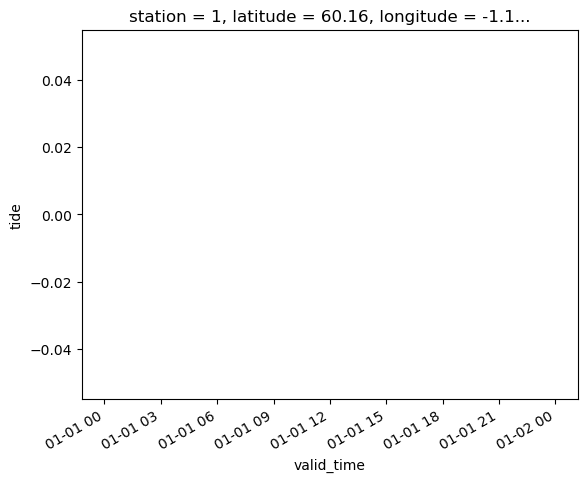

In [36]:
combined.sel(station=1).tide.plot()